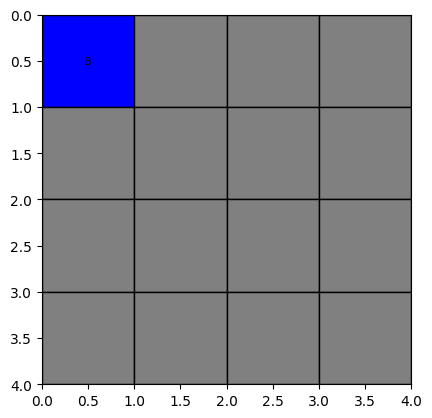

Step 1: Agent at (0, 0), Percepts=['Breeze'], Inference Steps=1


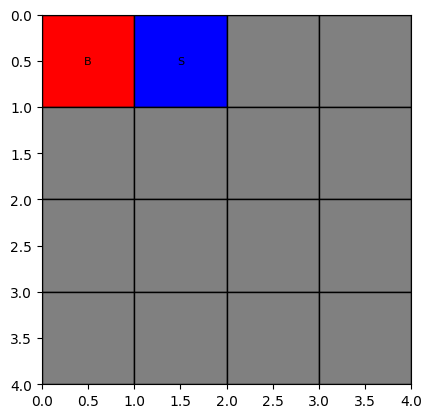

Step 2: Agent at (0, 1), Percepts=['Stench'], Inference Steps=4


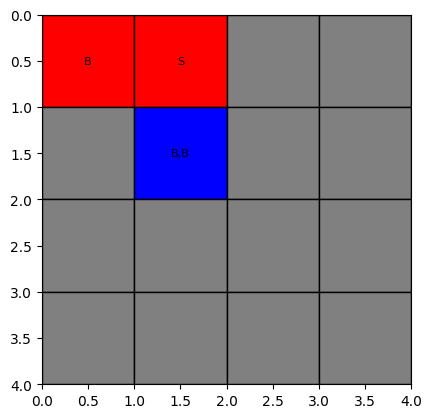

Step 3: Agent at (1, 1), Percepts=['Breeze', 'Breeze'], Inference Steps=8


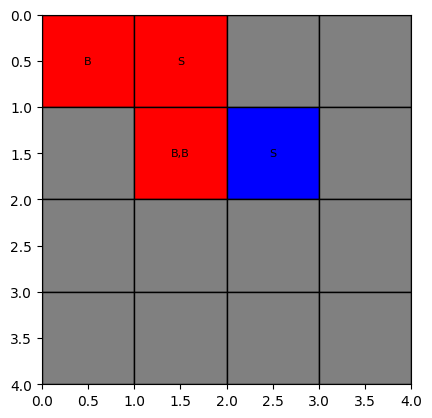

Step 4: Agent at (1, 2), Percepts=['Stench'], Inference Steps=13


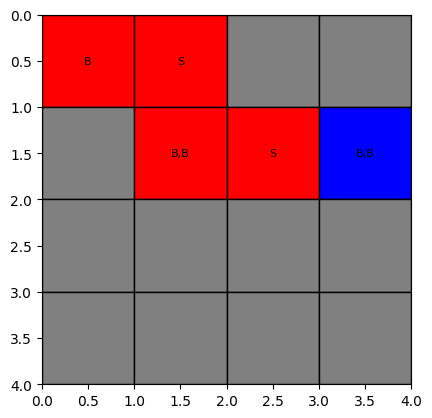

Step 5: Agent at (1, 3), Percepts=['Breeze', 'Breeze'], Inference Steps=18


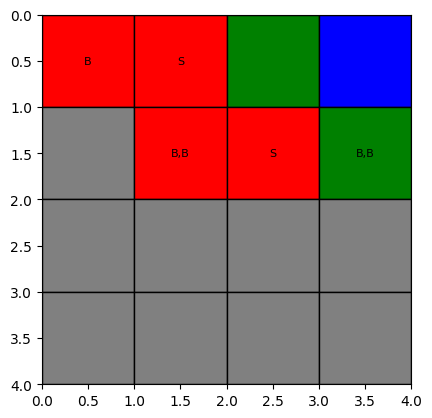

Step 6: Agent at (0, 3), Percepts=[], Inference Steps=22


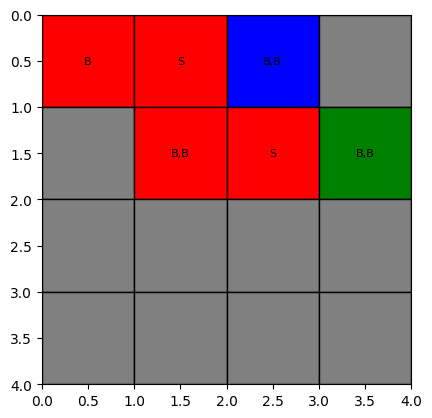

Step 7: Agent at (0, 2), Percepts=['Breeze', 'Breeze'], Inference Steps=25
No moves left, stopping.
Episode finished.


In [2]:
import random
import matplotlib.pyplot as plt

# --- Environment Setup ---
class WumpusWorld:
    def __init__(self, rows=4, cols=4, num_pits=3):
        self.rows = rows
        self.cols = cols
        self.pits = set()
        self.wumpus = None
        self.place_hazards(num_pits)

    def place_hazards(self, num_pits):
        while len(self.pits) < num_pits:
            r, c = random.randint(0, self.rows-1), random.randint(0, self.cols-1)
            if (r, c) != (0, 0):
                self.pits.add((r, c))
        while True:
            r, c = random.randint(0, self.rows-1), random.randint(0, self.cols-1)
            if (r, c) != (0, 0) and (r, c) not in self.pits:
                self.wumpus = (r, c)
                break

    def percepts(self, r, c):
        adj = [(r-1,c),(r+1,c),(r,c-1),(r,c+1)]
        percepts = []
        for (ar,ac) in adj:
            if 0 <= ar < self.rows and 0 <= ac < self.cols:
                if (ar,ac) in self.pits:
                    percepts.append("Breeze")
                if (ar,ac) == self.wumpus:
                    percepts.append("Stench")
        return percepts

# --- Knowledge Base ---
class KnowledgeBase:
    def __init__(self):
        self.safe = set()
        self.unsafe = set()
        self.visited = set()
        self.steps = 0

    def tell(self, cell, percepts, world):
        self.visited.add(cell)
        self.steps += 1
        if "Breeze" not in percepts and "Stench" not in percepts:
            for (ar,ac) in [(cell[0]-1,cell[1]),(cell[0]+1,cell[1]),
                            (cell[0],cell[1]-1),(cell[0],cell[1]+1)]:
                if 0 <= ar < world.rows and 0 <= ac < world.cols:
                    self.safe.add((ar,ac))
        else:
            self.unsafe.add(cell)

    def ask_safe(self, cell):
        self.steps += 1
        return cell in self.safe

# --- Visualization ---
def visualize(world, kb, agent_pos):
    fig, ax = plt.subplots()
    for r in range(world.rows):
        for c in range(world.cols):
            color = "gray"
            if (r,c) in kb.safe:
                color = "green"
            elif (r,c) in kb.unsafe:
                color = "red"
            if (r,c) == agent_pos:
                color = "blue"
            rect = plt.Rectangle((c,r),1,1,facecolor=color,edgecolor="black")
            ax.add_patch(rect)
            percepts = world.percepts(r,c)
            if (r,c) in kb.visited:
                ax.text(c+0.5,r+0.5,",".join(p[0] for p in percepts),
                        ha="center",va="center",fontsize=8)
    ax.set_xlim(0,world.cols)
    ax.set_ylim(0,world.rows)
    ax.set_aspect("equal")
    plt.gca().invert_yaxis()
    plt.show()

# --- Agent Simulation ---
def run_episode(rows=4, cols=4, num_pits=3, max_steps=10):
    world = WumpusWorld(rows, cols, num_pits)
    kb = KnowledgeBase()
    agent_pos = (0,0)

    for step in range(max_steps):
        percepts = world.percepts(*agent_pos)
        kb.tell(agent_pos, percepts, world)
        visualize(world, kb, agent_pos)
        print(f"Step {step+1}: Agent at {agent_pos}, Percepts={percepts}, Inference Steps={kb.steps}")

        # Choose next move: prefer safe unvisited cells
        candidates = [(agent_pos[0]-1,agent_pos[1]),(agent_pos[0]+1,agent_pos[1]),
                      (agent_pos[0],agent_pos[1]-1),(agent_pos[0],agent_pos[1]+1)]
        candidates = [(r,c) for (r,c) in candidates if 0 <= r < rows and 0 <= c < cols]

        safe_moves = [c for c in candidates if kb.ask_safe(c) and c not in kb.visited]
        if safe_moves:
            agent_pos = random.choice(safe_moves)
        else:
            # fallback: random unvisited cell
            unvisited = [c for c in candidates if c not in kb.visited]
            if unvisited:
                agent_pos = random.choice(unvisited)
            else:
                print("No moves left, stopping.")
                break

    print("Episode finished.")

# --- Run the game ---
run_episode(rows=4, cols=4, num_pits=3, max_steps=12)
